In [3]:
import numpy as np
import pandas as pd

%precision 3
pd.set_option('display.precision', 3)

In [6]:
df = pd.read_csv('/home/jovyan/data/ch2_scores_em.csv', index_col='生徒番号')
df.head()

,英語,数学
生徒番号,,
1,42,65
2,69,80
3,56,63
4,41,63
5,57,76


In [8]:
en_scores = np.array(df['英語'])[:10]
ma_scores = np.array(df['数学'])[:10]
scores_df = pd.DataFrame({'英語': en_scores, '数学': ma_scores}, index=pd.Index(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'], name='生徒'))
scores_df

,英語,数学
生徒,,
A,42,65
B,69,80
C,56,63
D,41,63
E,57,76
F,48,60
G,65,81
H,49,66
I,65,78


In [ ]:
summary_df = scores_df.copy()
summary_df['英語の偏差'] = summary_df['英語'] - summary_df['英語'].mean()
summary_df['数学の偏差'] = summary_df['数学'] - summary_df['数学'].mean()
summary_df['偏差同士の積'] = summary_df['英語の偏差'] * summary_df['数学の偏差']
summary_df


,英語,数学,英語の偏差,数学の偏差,偏差同士の積
生徒,,,,,
A,42,65,-13.0,-6.4,83.2
B,69,80,14.0,8.6,120.4
C,56,63,1.0,-8.4,-8.4
D,41,63,-14.0,-8.4,117.6
E,57,76,2.0,4.6,9.2
F,48,60,-7.0,-11.4,79.8
G,65,81,10.0,9.6,96.0
H,49,66,-6.0,-5.4,32.4
I,65,78,10.0,6.6,66.0


In [12]:
summary_df['偏差同士の積'].mean()

62.800

In [13]:
cov_mat = np.cov(en_scores, ma_scores, ddof=0)
cov_mat

array([[86.  , 62.8 ],
       [62.8 , 68.44]])

In [14]:
cov_mat[0, 1], cov_mat[1, 1]

(62.800, 68.440)

In [15]:
cov_mat[0, 0], cov_mat[1, 1]

(86.000, 68.440)

In [16]:
np.var(en_scores, ddof=0), np.var(ma_scores, ddof=0)

(86.000, 68.440)

In [17]:
np.cov(en_scores, ma_scores, ddof=0)[0, 1] / (np.std(en_scores) * np.std(ma_scores))

0.819

In [18]:
np.corrcoef(en_scores, ma_scores)

array([[1.   , 0.819],
       [0.819, 1.   ]])

In [19]:
scores_df.corr()

,英語,数学
英語,1.000,0.819
数学,0.819,1.000


In [22]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "IPAexGothic"
plt.rcParams["axes.unicode_minus"] = False

%matplotlib inline

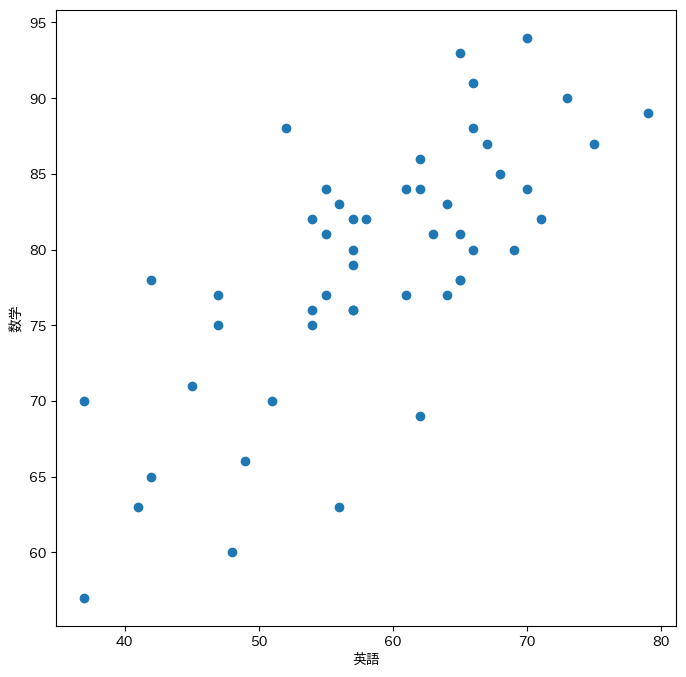

In [23]:
english_scores = np.array(df['英語'])
math_scores = np.array(df['数学'])

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)

ax.scatter(english_scores, math_scores)
ax.set_xlabel('英語')
ax.set_ylabel('数学')

plt.show()

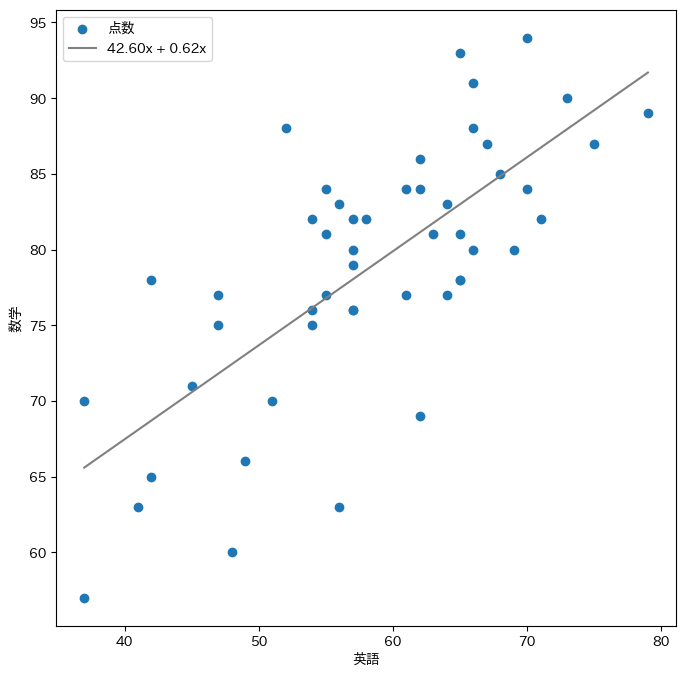

In [27]:
poly_fit = np.polyfit(english_scores, math_scores, 1)
poly_ld = np.poly1d(poly_fit)
xs = np.linspace(english_scores.min(), english_scores.max(), 100)
ys = poly_ld(xs)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)
ax.set_xlabel('英語')
ax.set_ylabel('数学')
ax.scatter(english_scores, math_scores, label='点数')
ax.plot(xs, ys, color='grey', label=f'{poly_fit[1]:.2f}x + {poly_fit[0]:.2f}x')

ax.legend(loc='upper left')

plt.show()

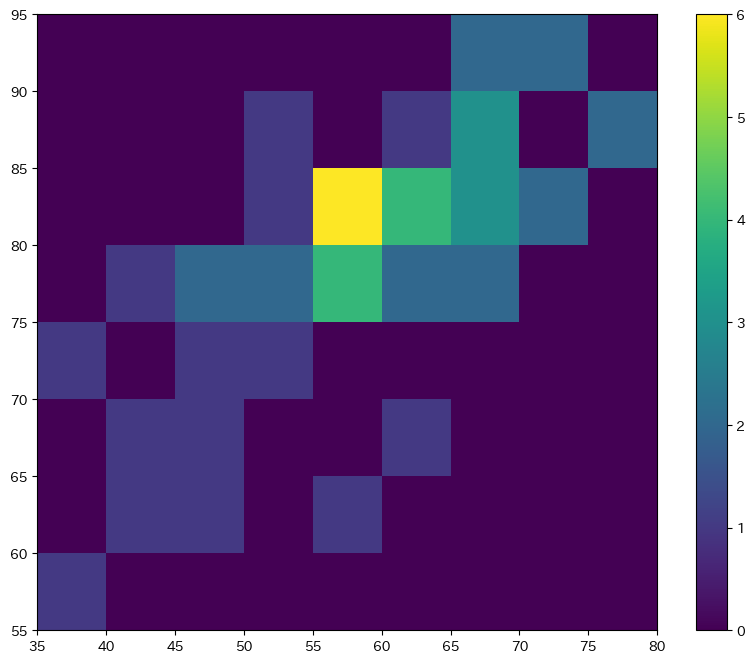

In [28]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

c = ax.hist2d(english_scores, math_scores, bins=[9, 8], range=[[35, 80], [55, 95]])
ax.set_xticks(c[1])
ax.set_yticks(c[2])

fig.colorbar(c[3], ax=ax)
plt.show()

In [30]:
anscombe_data = np.load('/home/jovyan/data/ch3_anscombe.npy')
print(anscombe_data.shape)
anscombe_data[0]

(4, 11, 2)


array([[10.  ,  8.04],
       [ 8.  ,  6.95],
       [13.  ,  7.58],
       [ 9.  ,  8.81],
       [11.  ,  8.33],
       [14.  ,  9.96],
       [ 6.  ,  7.24],
       [ 4.  ,  4.26],
       [12.  , 10.84],
       [ 7.  ,  4.82],
       [ 5.  ,  5.68]])

In [32]:
stats_df = pd.DataFrame(index=['Xの平均', 'Xの分散', 'Yの平均', 'Yの分散', 'XとYの相関係数', 'XとYの回帰直線'])

for i, data in enumerate(anscombe_data):
    dataX = data[:, 0]
    dataY = data[:, 1]
    poly_fit = np.polyfit(dataX, dataY, 1)
    stats_df[f'data{i + 1}'] = \
        [f'{np.mean(dataX):.2f}',
        f'{np.var(dataX):.2f}', 
        f'{np.mean(dataY):.2f}', 
        f'{np.var(dataY):.2f}', 
        f'{np.corrcoef(dataX, dataY)[0, 1]:.2f}',
        f'{poly_fit[1]:.2f}+{poly_fit[0]:.2f}x' ]
stats_df


,data1,data2,data3,data4
Xの平均,9.00,9.00,9.00,9.00
Xの分散,10.00,10.00,10.00,10.00
Yの平均,7.50,7.50,7.50,7.50
Yの分散,3.75,3.75,3.75,3.75
XとYの相関係数,0.82,0.82,0.82,0.82
XとYの回帰直線,3.00+0.50x,3.00+0.50x,3.00+0.50x,3.00+0.50x


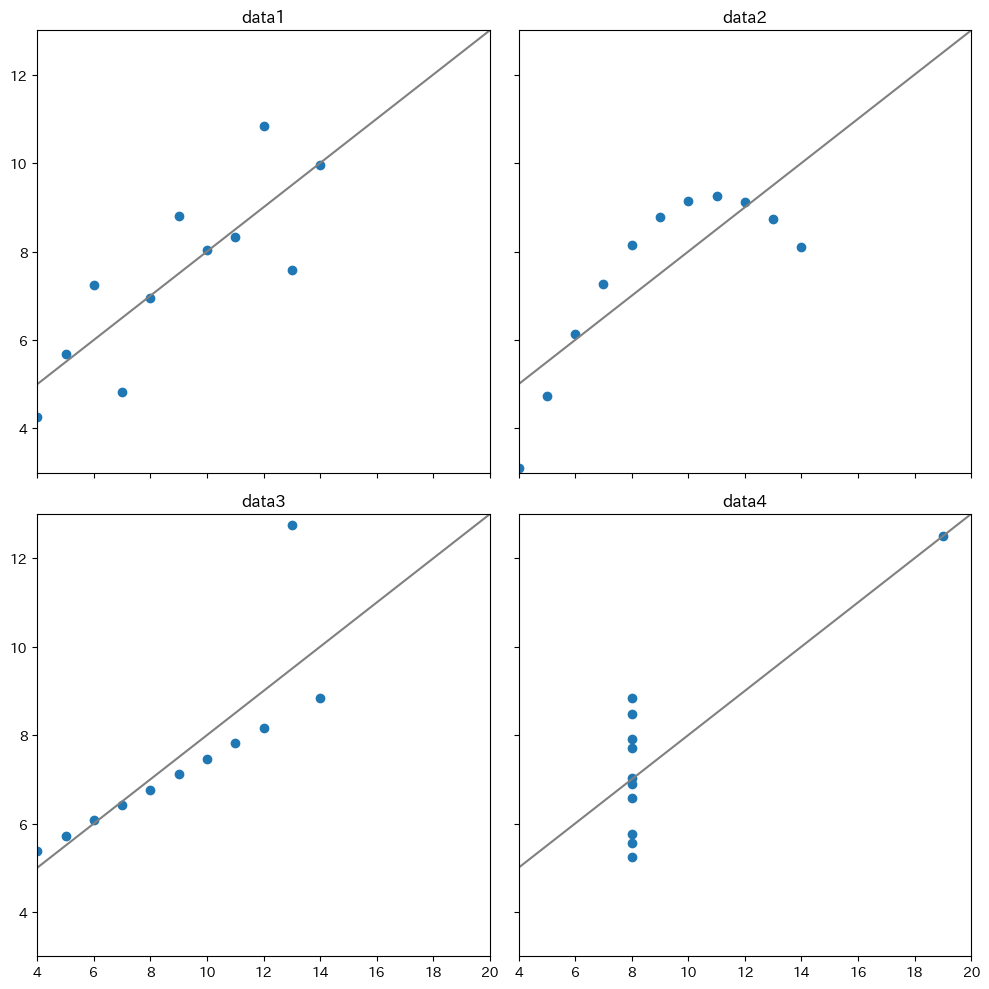

In [34]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10), sharex=True, sharey=True)

xs = np.linspace(0, 30, 100)
for i, data in enumerate(anscombe_data):
    poly_fit = np.polyfit(data[:, 0], data[:, 1], 1)
    poly_ld = np.poly1d(poly_fit)
    ys = poly_ld(xs)
    
    ax = axes[i // 2, i % 2]
    ax.set_xlim([4, 20])
    ax.set_ylim([3, 13])

    ax.set_title(f'data{i + 1}')
    ax.scatter(data[:, 0], data[:, 1])
    ax.plot(xs, ys, color='grey')

plt.tight_layout()
plt.show()

In [42]:
import math as ma

arr = [18, 27, 38, 45, 72, 87, 91, 101]
np.mean(arr)


59.875

In [43]:
 np.median(arr)

58.500

In [44]:
np.unique(arr, return_counts=True)

(array([ 18,  27,  38,  45,  72,  87,  91, 101]),
 array([1, 1, 1, 1, 1, 1, 1, 1]))

In [45]:
np.ptp(arr)

np.int64(83)